# Analyze merged TMC sweep results

Set `RUN_FOLDER` and `TARGET_ISLAND` in Cell 2 to reuse this notebook for any merged run.

This notebook analyzes merged sweep output and focuses on island rankings across permutations and calibration fractions.

In [115]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS (edit these)
# =========================
RUN_FOLDER = "outputs/tmc_shapley_sweep4"   # Relative or absolute path to merged sweep folder
TARGET_ISLAND = 4                            # Island code used in cache filenames

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Configured run folder:", RUN_FOLDER)
print("Configured target island:", TARGET_ISLAND)

Configured run folder: outputs/tmc_shapley_sweep4
Configured target island: 4


In [116]:
# Locate run folder
cwd = Path.cwd().resolve()
workspace_root = cwd
requested_path = Path(RUN_FOLDER)

if requested_path.is_absolute():
    sweep_dir = requested_path
else:
    sweep_dir = None
    for parent in [cwd, *cwd.parents]:
        candidate = (parent / requested_path).resolve()
        if candidate.exists():
            workspace_root = parent
            sweep_dir = candidate
            break
    if sweep_dir is None:
        sweep_dir = (cwd / requested_path).resolve()

if not sweep_dir.exists():
    raise FileNotFoundError(f"Could not find run folder: {sweep_dir}")

print(f"Workspace root: {workspace_root}")
print(f"Run folder:     {sweep_dir}")
print(f"Target island:  {TARGET_ISLAND}")

Workspace root: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
Run folder:     C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_shapley_sweep4
Target island:  4


## 1) Load merged outputs

In [117]:
summary_json = json.loads((sweep_dir / "sweep_summary.json").read_text(encoding="utf-8"))
meta_df = pd.read_csv(sweep_dir / "sweep_run_metadata.csv")

surface_candidates = [
    sweep_dir / "gain_over_baseline_surface_data.csv",
    sweep_dir / "gain_over_vfull_surface_data.csv",
]
surface_path = next((p for p in surface_candidates if p.exists()), None)
if surface_path is None:
    raise FileNotFoundError(
        f"Could not find gain surface CSV. Tried: {[str(p) for p in surface_candidates]}"
    )

surface_df = pd.read_csv(surface_path)
remove_summary_df = pd.read_csv(sweep_dir / "remove_curve_sweep_summary.csv")

print(json.dumps(summary_json, indent=2))
print("Using surface file:", surface_path.name)
display(meta_df.head())
display(surface_df.head())
display(remove_summary_df.head())

{
  "n_shards_found": 5,
  "n_permutations": [
    10,
    20,
    40,
    60
  ],
  "cal_fractions": [
    0.05,
    0.1,
    0.15,
    0.2,
    0.25
  ],
  "n_successful_runs": 200,
  "outputs": {
    "remove_curve_sweep_rows": "outputs\\tmc_shapley_sweep4\\remove_curve_sweep_rows.csv",
    "remove_curve_sweep_summary": "outputs\\tmc_shapley_sweep4\\remove_curve_sweep_summary.csv",
    "sweep_run_metadata": "outputs\\tmc_shapley_sweep4\\sweep_run_metadata.csv",
    "gain_over_baseline_surface_data": "outputs\\tmc_shapley_sweep4\\gain_over_baseline_surface_data.csv",
    "remove_curve_grid_plot": "outputs\\tmc_shapley_sweep4\\remove_curve_grid.png",
    "gain_surface_3d_plot": "outputs\\tmc_shapley_sweep4\\gain_over_baseline_surface_3d.png"
  }
}
Using surface file: gain_over_baseline_surface_data.csv


,target_island,target_island_name,repeat,split_seed,n_permutations,cal_fraction,v_full,n_source_islands
0,4,Gjerøy,0,71745746,10,0.05,-0.143953,15
1,4,Gjerøy,5,1853840178,10,0.05,-0.035380,15
2,4,Gjerøy,0,71745746,20,0.05,-0.143953,15
3,4,Gjerøy,5,1853840178,20,0.05,-0.035380,15
4,4,Gjerøy,0,71745746,40,0.05,-0.143953,15


,n_permutations,cal_fraction,best_n_removed,best_n_islands,best_corr_mean,corr_baseline,v_full_mean,gain_over_baseline,n_runs
0,10,0.05,3,12,0.098535,0.091248,0.008814,0.007288,10
1,10,0.10,2,13,0.102789,0.091493,0.116697,0.011297,10
2,10,0.15,7,8,0.107703,0.084017,0.128974,0.023686,10
3,10,0.20,6,9,0.138718,0.102548,0.023621,0.036171,10
4,10,0.25,5,10,0.119684,0.084254,0.095743,0.035431,10


,n_permutations,cal_fraction,method,n_removed,corr_mean,corr_std,mse_mean,mse_std,n_rows
0,10,0.05,random_individual,0,0.091248,0.034028,1.480963,0.060160,50
1,10,0.05,random_individual,1,0.090590,0.032961,1.481200,0.059234,50
2,10,0.05,random_individual,2,0.090189,0.036235,1.481533,0.059199,50
3,10,0.05,random_individual,3,0.091160,0.034839,1.481049,0.059729,50
4,10,0.05,random_individual,4,0.090464,0.036151,1.481300,0.060438,50


In [118]:
# High-level consistency checks
print("n rows in metadata:", len(meta_df))
print("unique cal fractions:", sorted(meta_df["cal_fraction"].unique()))
print("unique n_permutations:", sorted(meta_df["n_permutations"].unique()))
print("unique repeats:", sorted(meta_df["repeat"].unique()))
print("unique split seeds:", meta_df["split_seed"].nunique())


def get_cal_sample_map(target_island: int) -> dict:
    """Return mapping {cal_fraction: median_cal_samples} from shard split plans."""
    split_plan_files = sorted(sweep_dir.glob("shards/shard_*/target_split_plan.csv"))
    if not split_plan_files:
        return {}

    parts = []
    for p in split_plan_files:
        try:
            parts.append(pd.read_csv(p))
        except Exception:
            continue

    if not parts:
        return {}

    split_df = pd.concat(parts, ignore_index=True)
    required_cols = {"target_island", "cal_fraction", "repeat", "subset", "ringnr"}
    if not required_cols.issubset(split_df.columns):
        return {}

    cal_df = split_df[
        (split_df["subset"] == "cal")
        & (split_df["target_island"].astype(int) == int(target_island))
    ].copy()
    if cal_df.empty:
        return {}

    cal_counts = (
        cal_df.groupby(["cal_fraction", "repeat"], as_index=False)["ringnr"]
        .nunique()
        .rename(columns={"ringnr": "cal_samples"})
    )

    map_df = cal_counts.groupby("cal_fraction", as_index=False)["cal_samples"].median()
    return {float(r["cal_fraction"]): int(r["cal_samples"]) for _, r in map_df.iterrows()}


cal_samples_map = get_cal_sample_map(TARGET_ISLAND)
if cal_samples_map:
    print("cal_fraction -> cal_samples (from split plans):")
    print(dict(sorted(cal_samples_map.items())))
else:
    print("cal_samples map unavailable (missing split plans or target not found in split plans).")

n rows in metadata: 200
unique cal fractions: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]
unique n_permutations: [np.int64(10), np.int64(20), np.int64(40), np.int64(60)]
unique repeats: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
unique split seeds: 50


cal_fraction -> cal_samples (from split plans):
{0.05: 27, 0.1: 55, 0.15: 83, 0.2: 111, 0.25: 139}


## 2) Build running island rankings from cache states

Each cache file stores per-permutation local Shapley contributions for one split seed.
We reconstruct running mean Shapley values and convert them to running ranks (1 = highest).

In [119]:
# Island id -> name mapping from one intermediate ranking file
sample_intermediate_files = sorted(sweep_dir.glob("shards/shard_*/tmp/tmc_intermediate_rankings_target_*.csv"))
if not sample_intermediate_files:
    raise FileNotFoundError("No intermediate ranking CSV found under shards/shard_*/tmp/")

name_map_df = pd.read_csv(sample_intermediate_files[0], usecols=["source_island", "source_island_name"])
name_map = (
    name_map_df.drop_duplicates("source_island")
    .sort_values("source_island")
    .set_index("source_island")["source_island_name"]
    .to_dict()
)

# Find cache files for configured target island; fallback when there is exactly one target available
cache_root = sweep_dir / "cache"
cache_files = sorted(cache_root.glob(f"tmc_perm_state_target_{TARGET_ISLAND}_seed_*.json"))

if not cache_files:
    # Parse available targets from cache filenames
    all_cache_files = sorted(cache_root.glob("tmc_perm_state_target_*_seed_*.json"))
    cache_targets = sorted({int(p.stem.split("_target_")[1].split("_seed_")[0]) for p in all_cache_files})

    # Targets present in merged metadata
    meta_targets = sorted(meta_df["target_island"].astype(int).unique().tolist())

    fallback_target = None
    if len(meta_targets) == 1:
        fallback_target = int(meta_targets[0])
    elif len(cache_targets) == 1:
        fallback_target = int(cache_targets[0])

    if fallback_target is not None:
        print(
            f"No cache files for TARGET_ISLAND={TARGET_ISLAND}. "
            f"Falling back to target island {fallback_target}."
        )
        TARGET_ISLAND = fallback_target
        cache_files = sorted(cache_root.glob(f"tmc_perm_state_target_{TARGET_ISLAND}_seed_*.json"))

if not cache_files:
    raise FileNotFoundError(
        "No cache state files found. "
        f"Configured target={TARGET_ISLAND}, metadata targets={sorted(meta_df['target_island'].unique())}, "
        f"cache dir={cache_root}"
    )

print(f"Using {len(cache_files)} cache files for target island {TARGET_ISLAND}")

# Use one metadata row per split seed for cal_fraction mapping
seed_meta = (
    meta_df.sort_values(["split_seed", "n_permutations"])
    .groupby("split_seed", as_index=False)
    .first()
    [["split_seed", "repeat", "cal_fraction", "target_island", "target_island_name", "v_full"]]
)
seed_meta_map = seed_meta.set_index("split_seed").to_dict(orient="index")

rows = []
for file_path in cache_files:
    state = json.loads(file_path.read_text(encoding="utf-8"))
    seed = int(state["seed"])
    if seed not in seed_meta_map:
        continue

    local_phi = np.array(state.get("local_phi_by_perm", []), dtype=float)
    if local_phi.ndim != 2 or local_phi.size == 0:
        continue

    n_perm, n_islands = local_phi.shape
    running_phi = np.cumsum(local_phi, axis=0) / np.arange(1, n_perm + 1)[:, None]

    order = np.argsort(-running_phi, axis=1)
    ranks = np.empty_like(order)
    ranks[np.arange(n_perm)[:, None], order] = np.arange(1, n_islands + 1)

    meta = seed_meta_map[seed]
    for perm_idx in range(n_perm):
        for source_island in range(n_islands):
            rows.append({
                "split_seed": seed,
                "repeat": int(meta["repeat"]),
                "cal_fraction": float(meta["cal_fraction"]),
                "target_island": int(meta["target_island"]),
                "target_island_name": meta["target_island_name"],
                "v_full": float(meta["v_full"]),
                "permutation_index": perm_idx + 1,
                "source_island": source_island,
                "source_island_name": name_map.get(source_island, f"island_{source_island}"),
                "phi_running": float(running_phi[perm_idx, source_island]),
                "rank_running": int(ranks[perm_idx, source_island]),
            })

rank_long = pd.DataFrame(rows)
print("Rank rows:", len(rank_long))
print("Seeds loaded:", rank_long["split_seed"].nunique())
print("Permutation max:", rank_long["permutation_index"].max())
display(rank_long.head())

Using 50 cache files for target island 4
Rank rows: 45000
Seeds loaded: 50
Permutation max: 60


,split_seed,repeat,cal_fraction,target_island,target_island_name,v_full,permutation_index,source_island,source_island_name,phi_running,rank_running
0,106334331,3,0.25,4,Gjerøy,0.120702,1,0,Nesøy,-0.002759,8
1,106334331,3,0.25,4,Gjerøy,0.120702,1,1,Myken,-0.004032,9
2,106334331,3,0.25,4,Gjerøy,0.120702,1,2,Træna,0.000719,7
3,106334331,3,0.25,4,Gjerøy,0.120702,1,3,Selvær,-0.006234,10
4,106334331,3,0.25,4,Gjerøy,0.120702,1,4,island_4,0.145194,1


## 3) Overview figure: rankings across permutations and cal fractions

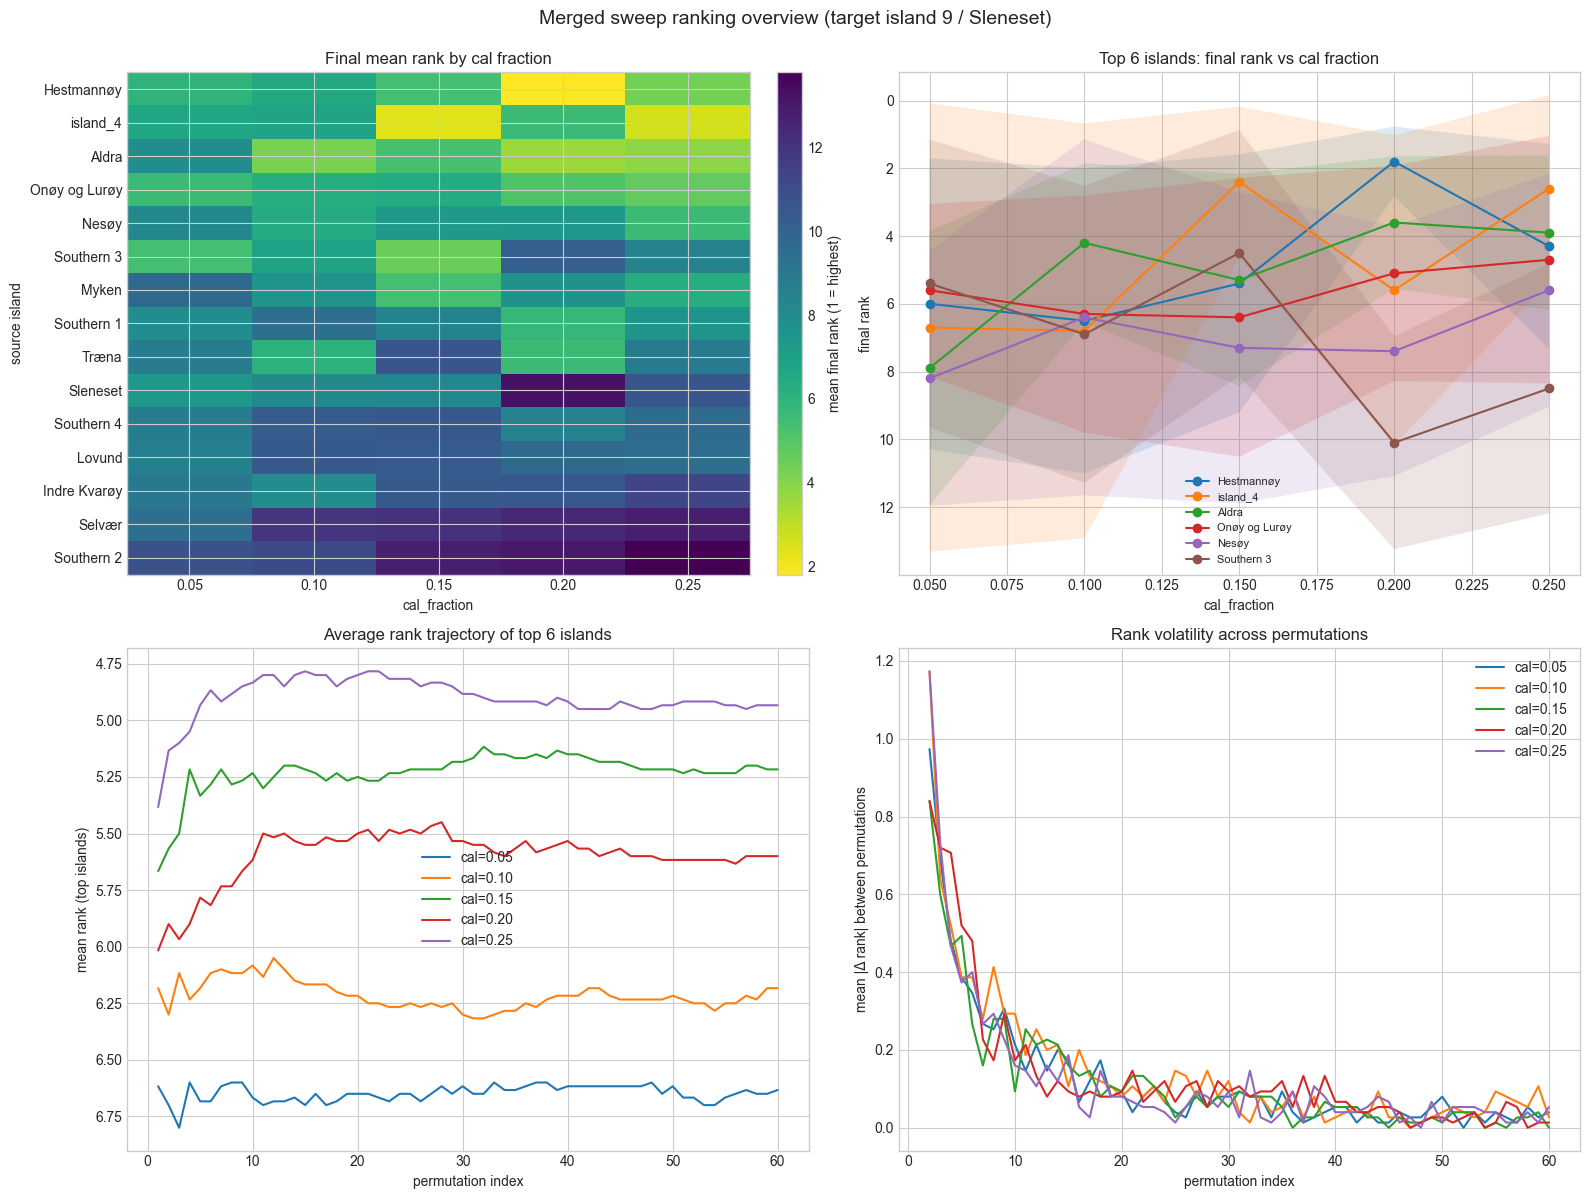

In [120]:
max_perm = int(rank_long["permutation_index"].max())
final_ranks = rank_long[rank_long["permutation_index"] == max_perm].copy()

# Final rank mean per cal fraction and island
final_rank_mean = (
    final_ranks.groupby(["cal_fraction", "source_island_name"], as_index=False)["rank_running"]
    .mean()
    .rename(columns={"rank_running": "final_rank_mean"})
)

island_order = (
    final_rank_mean.groupby("source_island_name", as_index=False)["final_rank_mean"]
    .mean()
    .sort_values("final_rank_mean")
)["source_island_name"].tolist()
cal_order = sorted(final_rank_mean["cal_fraction"].unique())

heat = (
    final_rank_mean.pivot(index="source_island_name", columns="cal_fraction", values="final_rank_mean")
    .reindex(index=island_order, columns=cal_order)
)

# Choose top islands by overall final rank
top_k = 6
top_islands = island_order[:top_k]

traj = rank_long[rank_long["source_island_name"].isin(top_islands)].copy()
traj_stats = (
    traj.groupby(["cal_fraction", "source_island_name", "permutation_index"], as_index=False)["rank_running"]
    .agg(rank_mean="mean", rank_std="std")
)

# Rank volatility: mean |delta rank| across islands per seed and permutation
seed_perm_mean = (
    rank_long.groupby(["cal_fraction", "split_seed", "permutation_index", "source_island"], as_index=False)["rank_running"]
    .mean()
)
seed_perm_mean = seed_perm_mean.sort_values(["cal_fraction", "split_seed", "source_island", "permutation_index"])
seed_perm_mean["rank_delta"] = seed_perm_mean.groupby(["cal_fraction", "split_seed", "source_island"])["rank_running"].diff().abs()
volatility = (
    seed_perm_mean.groupby(["cal_fraction", "permutation_index"], as_index=False)["rank_delta"]
    .mean()
    .rename(columns={"rank_delta": "mean_abs_rank_change"})
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: heatmap of final mean ranks
ax = axes[0, 0]
im = ax.imshow(heat.values, aspect="auto", cmap="viridis_r", interpolation="nearest")
ax.set_title("Final mean rank by cal fraction")
ax.set_xlabel("cal_fraction")
ax.set_ylabel("source island")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in heat.columns])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("mean final rank (1 = highest)")

# Panel B: final rank spread for top islands across cal fractions
ax = axes[0, 1]
for island in top_islands:
    g = final_ranks[final_ranks["source_island_name"] == island]
    stats = g.groupby("cal_fraction", as_index=False)["rank_running"].agg(["mean", "std"]).reset_index()
    ax.plot(stats["cal_fraction"], stats["mean"], marker="o", label=island)
    std_vals = stats["std"].fillna(0)
    ax.fill_between(stats["cal_fraction"], stats["mean"] - std_vals, stats["mean"] + std_vals, alpha=0.15)
ax.set_title(f"Top {top_k} islands: final rank vs cal fraction")
ax.set_xlabel("cal_fraction")
ax.set_ylabel("final rank")
ax.invert_yaxis()
ax.legend(loc="best", fontsize=8)

# Panel C: rank trajectory over permutations by cal fraction (top islands pooled)
ax = axes[1, 0]
for cf in cal_order:
    g = traj_stats[traj_stats["cal_fraction"] == cf]
    pooled = g.groupby("permutation_index", as_index=False)["rank_mean"].mean()
    ax.plot(pooled["permutation_index"], pooled["rank_mean"], label=f"cal={cf:.2f}")
ax.set_title(f"Average rank trajectory of top {top_k} islands")
ax.set_xlabel("permutation index")
ax.set_ylabel("mean rank (top islands)")
ax.invert_yaxis()
ax.legend(loc="best")

# Panel D: rank volatility decay by cal fraction
ax = axes[1, 1]
for cf in cal_order:
    g = volatility[volatility["cal_fraction"] == cf]
    ax.plot(g["permutation_index"], g["mean_abs_rank_change"], label=f"cal={cf:.2f}")
ax.set_title("Rank volatility across permutations")
ax.set_xlabel("permutation index")
ax.set_ylabel("mean |Δ rank| between permutations")
ax.legend(loc="best")

fig.suptitle("Merged sweep ranking overview (target island 9 / Sleneset)", fontsize=14, y=0.995)
fig.tight_layout()
plt.show()

## 4) Detailed view: top-island trajectories per cal fraction

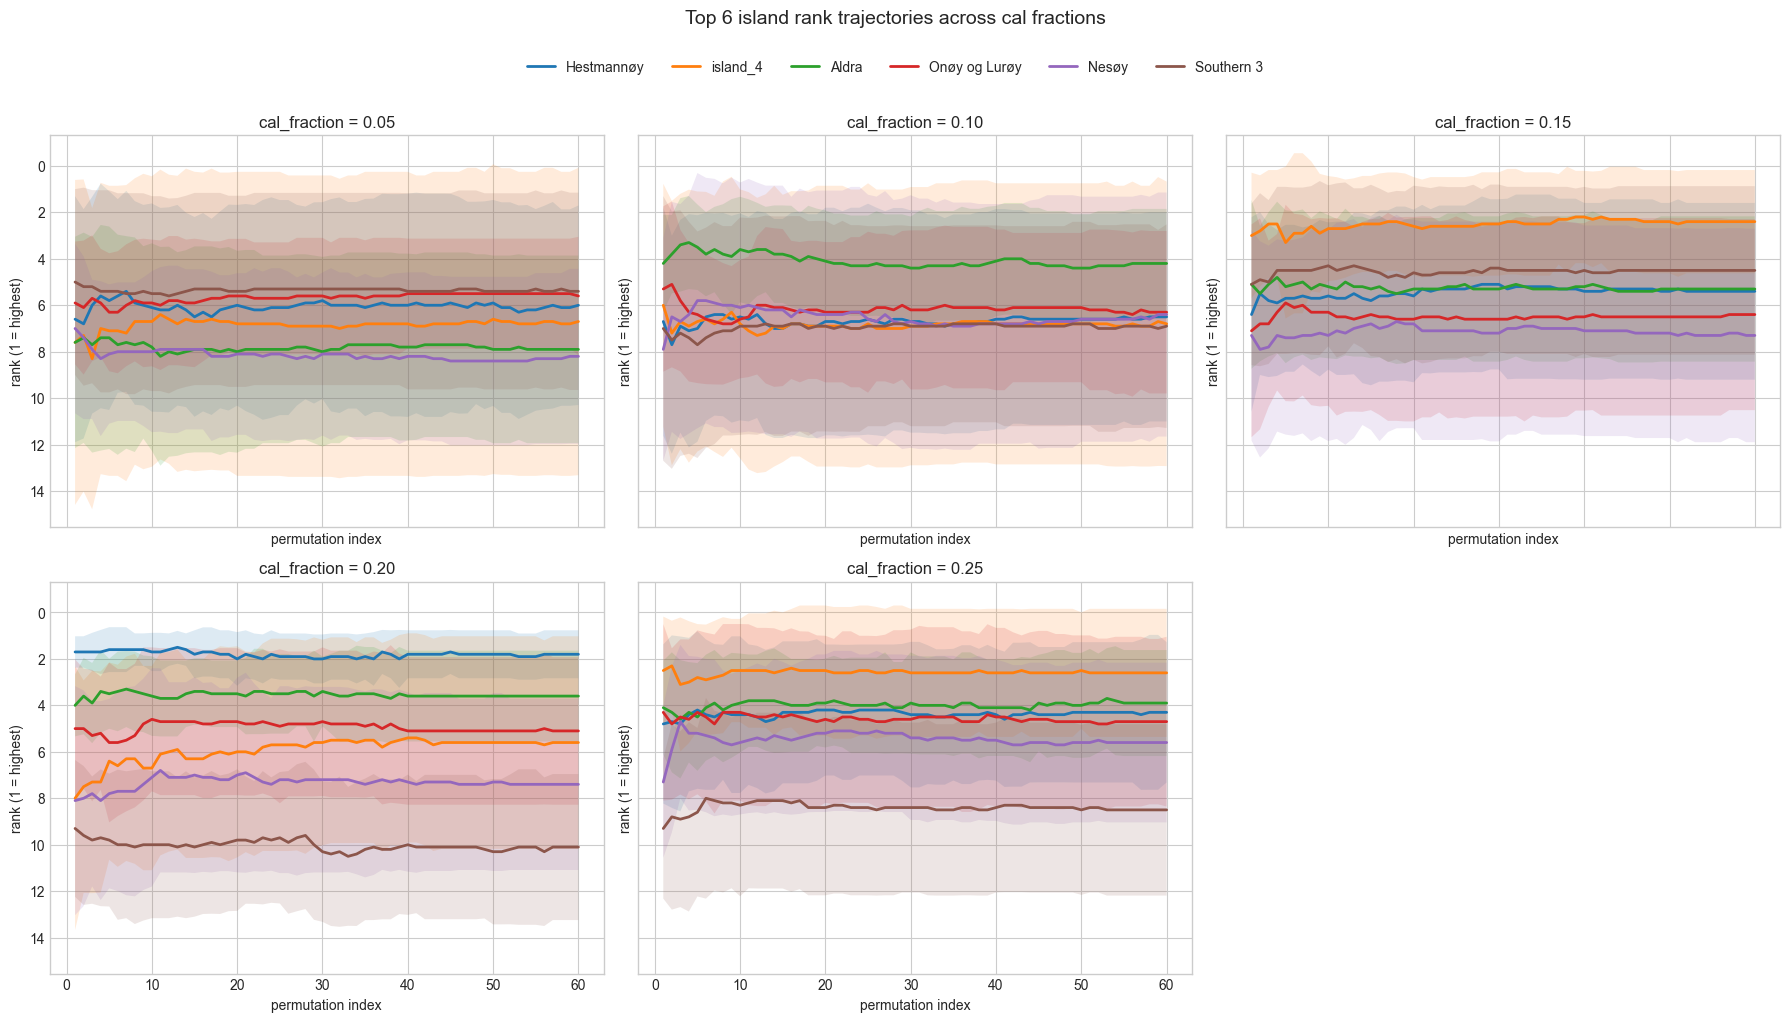

In [121]:
n_cols = 3
n_rows = int(np.ceil(len(cal_order) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for idx, cf in enumerate(cal_order):
    ax = axes[idx]
    g_cf = traj_stats[traj_stats["cal_fraction"] == cf]
    for island in top_islands:
        g = g_cf[g_cf["source_island_name"] == island].sort_values("permutation_index")
        if g.empty:
            continue
        ax.plot(g["permutation_index"], g["rank_mean"], label=island, linewidth=2)
        std_vals = g["rank_std"].fillna(0)
        ax.fill_between(g["permutation_index"], g["rank_mean"] - std_vals, g["rank_mean"] + std_vals, alpha=0.15)

    ax.set_title(f"cal_fraction = {cf:.2f}")
    ax.set_xlabel("permutation index")
    ax.set_ylabel("rank (1 = highest)")
    ax.invert_yaxis()

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6), bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"Top {top_k} island rank trajectories across cal fractions", y=1.06, fontsize=14)
fig.tight_layout()
plt.show()

## 5) Tables: most stable and most variable islands

Stability score here is the std of rank in the **last 20 permutations** (lower is more stable).

In [122]:
tail_window = 20
tail_start = max_perm - tail_window + 1
tail_df = rank_long[rank_long["permutation_index"] >= tail_start].copy()

stability_table = (
    tail_df.groupby(["cal_fraction", "source_island_name"], as_index=False)["rank_running"]
    .std()
    .rename(columns={"rank_running": "rank_std_last_window"})
    .sort_values(["cal_fraction", "rank_std_last_window", "source_island_name"])
)

print("Most stable islands per cal_fraction")
display(stability_table.groupby("cal_fraction", as_index=False).head(5))

print("Most variable islands per cal_fraction")
display(stability_table.groupby("cal_fraction", as_index=False).tail(5))

Most stable islands per cal_fraction


,cal_fraction,source_island_name,rank_std_last_window
6,0.05,Onøy og Lurøy,2.261759
4,0.05,Myken,2.926761
7,0.05,Selvær,3.038182
9,0.05,Southern 1,3.348708
13,0.05,Træna,3.386346
15,0.10,Aldra,2.248344
27,0.10,Southern 4,2.314473
18,0.10,Lovund,2.447309
28,0.10,Træna,2.470652
25,0.10,Southern 2,2.660260


Most variable islands per cal_fraction


,cal_fraction,source_island_name,rank_std_last_window
10,0.05,Southern 2,4.483706
2,0.05,Indre Kvarøy,4.499235
3,0.05,Lovund,4.558453
8,0.05,Sleneset,4.875072
14,0.05,island_4,6.248600
16,0.10,Hestmannøy,4.333474
17,0.10,Indre Kvarøy,4.695125
23,0.10,Sleneset,4.901964
20,0.10,Nesøy,5.031599
29,0.10,island_4,5.772990


## 6) 5×5 grid: bottom-5 islands by average rank per tile\n\nRows = calibration fractions, columns = max permutations (`n_permutations`).\nFor each tile, we select the 5 islands with worst (highest) average rank and plot their mean running-rank trajectories up to that permutation count.

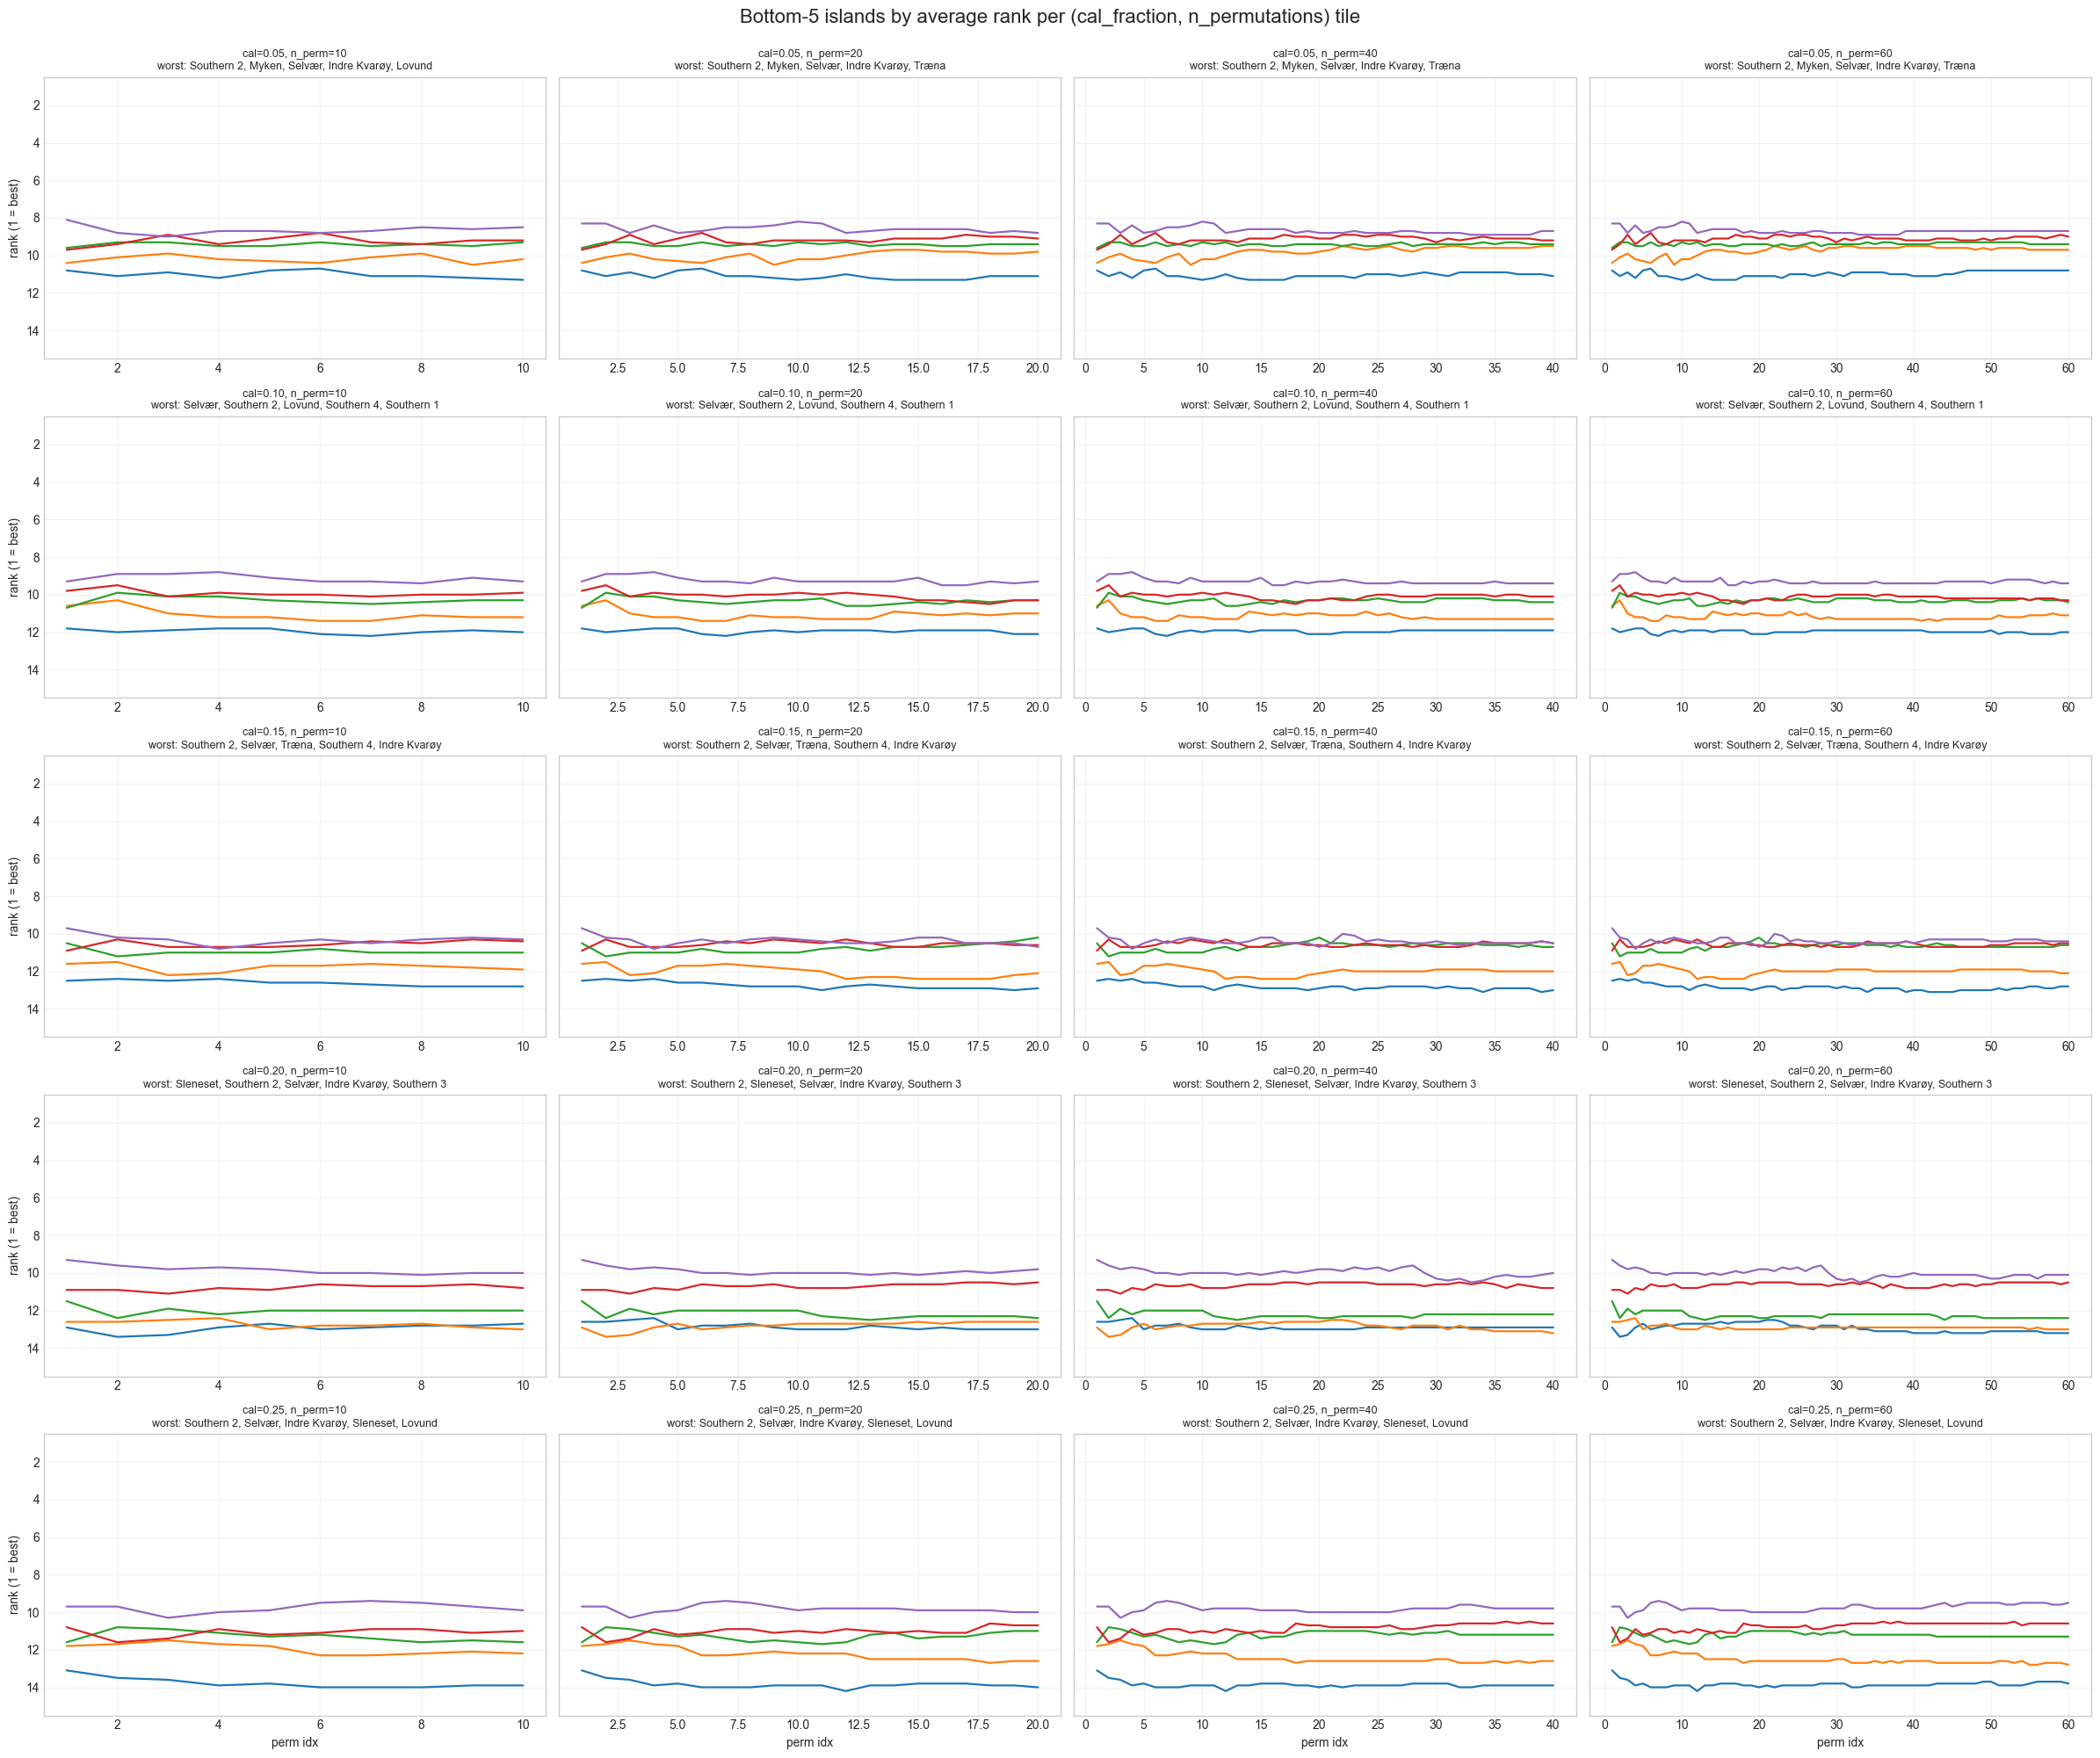

In [123]:
perm_grid = sorted(summary_json["n_permutations"])
cal_grid = sorted(summary_json["cal_fractions"])

fig, axes = plt.subplots(
    len(cal_grid),
    len(perm_grid),
    figsize=(24, 20),
    sharex=False,
    sharey=True,
)

for r, cf in enumerate(cal_grid):
    for c, np_max in enumerate(perm_grid):
        ax = axes[r, c]

        tile_df = rank_long[(rank_long["cal_fraction"] == cf) & (rank_long["permutation_index"] <= np_max)].copy()
        if tile_df.empty:
            ax.set_title(f"cal={cf:.2f}, n_perm={np_max}\n(no data)")
            ax.axis("off")
            continue

        worst5 = (
            tile_df.groupby("source_island_name", as_index=False)["rank_running"]
            .mean()
            .sort_values("rank_running", ascending=False)
            .head(5)
        )
        worst_names = worst5["source_island_name"].tolist()

        for island in worst_names:
            g = tile_df[tile_df["source_island_name"] == island]
            traj = g.groupby("permutation_index", as_index=False)["rank_running"].mean()
            ax.plot(traj["permutation_index"], traj["rank_running"], linewidth=1.6)

        ax.set_title(
            f"cal={cf:.2f}, n_perm={np_max}\nworst: {', '.join(worst_names)}",
            fontsize=9,
        )
        ax.set_ylim(15.5, 0.5)
        ax.grid(alpha=0.25)

        if r == len(cal_grid) - 1:
            ax.set_xlabel("perm idx")
        if c == 0:
            ax.set_ylabel("rank (1 = best)")

fig.suptitle("Bottom-5 islands by average rank per (cal_fraction, n_permutations) tile", fontsize=16, y=0.998)
fig.tight_layout()
plt.show()

Gain table (best remove-curve point vs n_removed=0, both on test set):


,n_permutations,cal_fraction,best_n_removed,corr_best,corr_baseline,gain_over_baseline
0,10,0.05,3,0.098535,0.091248,0.007288
5,20,0.05,5,0.097460,0.091248,0.006213
10,40,0.05,4,0.099217,0.091248,0.007970
15,60,0.05,4,0.099217,0.091248,0.007970
1,10,0.10,2,0.102789,0.091493,0.011297
6,20,0.10,2,0.100448,0.091493,0.008955
11,40,0.10,2,0.102789,0.091493,0.011297
16,60,0.10,2,0.103509,0.091493,0.012016
2,10,0.15,7,0.107703,0.084017,0.023686
7,20,0.15,7,0.106885,0.084017,0.022868


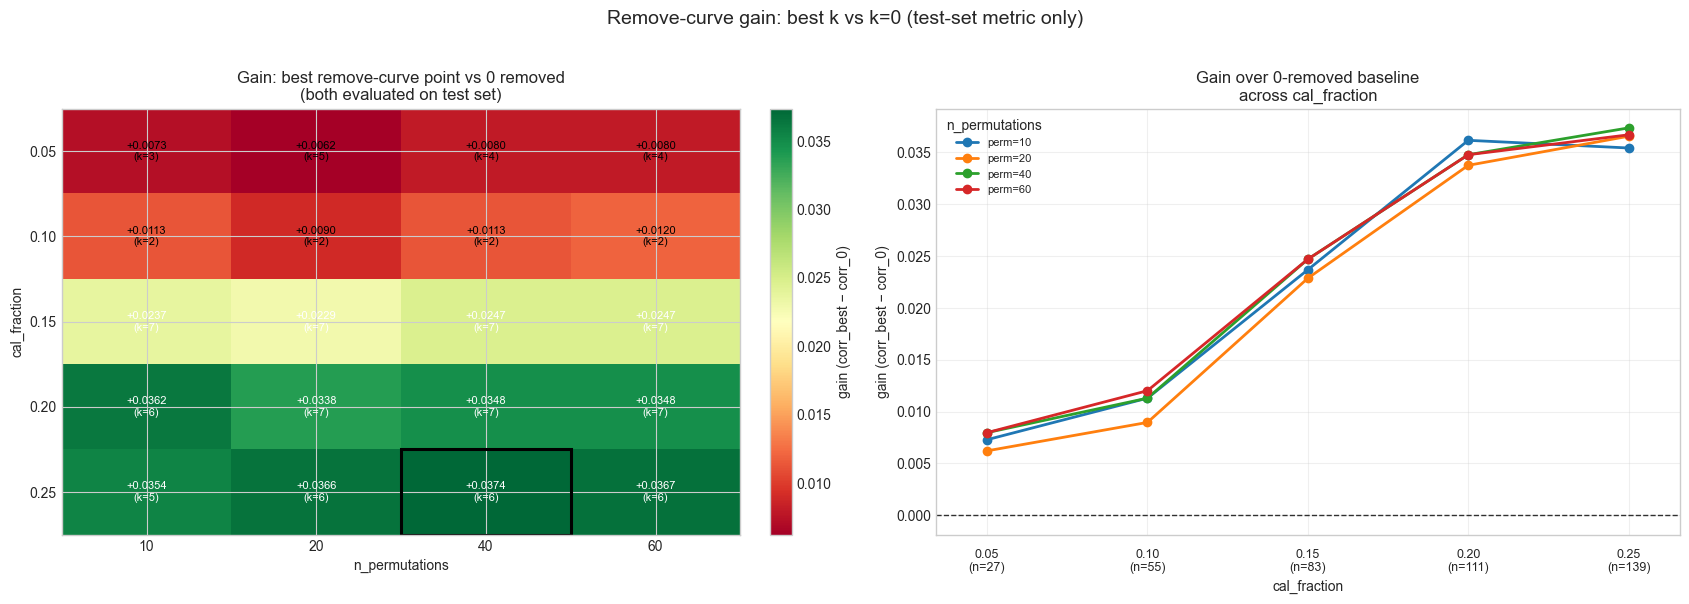

In [124]:
# Recompute gain: best remove-curve score vs n_removed=0 (both on TEST set)
import matplotlib.colors as mcolors

# Shapley remove-curve summary (already aggregated across repeats)
shap_rc = remove_summary_df[remove_summary_df["method"] == "shapley_mean"].copy()

# Baseline: n_removed=0 (all islands, evaluated on test set)
baseline = (
    shap_rc[shap_rc["n_removed"] == 0]
    .rename(columns={"corr_mean": "corr_baseline"})
    [["n_permutations", "cal_fraction", "corr_baseline"]]
)

# Best n_removed per (n_permutations, cal_fraction) cell
best_idx = shap_rc.groupby(["n_permutations", "cal_fraction"])["corr_mean"].idxmax()
best = shap_rc.loc[best_idx, ["n_permutations", "cal_fraction", "n_removed", "corr_mean"]].copy()
best = best.rename(columns={"corr_mean": "corr_best", "n_removed": "best_n_removed"})

# Merge and compute gain over baseline
gain_df = best.merge(baseline, on=["n_permutations", "cal_fraction"])
gain_df["gain_over_baseline"] = gain_df["corr_best"] - gain_df["corr_baseline"]

print("Gain table (best remove-curve point vs n_removed=0, both on test set):")
display(gain_df.sort_values(["cal_fraction", "n_permutations"]))

# --- Annotated heatmap ---
gain_grid = (
    gain_df.pivot(index="cal_fraction", columns="n_permutations", values="gain_over_baseline")
    .sort_index(axis=0).sort_index(axis=1)
)
best_n_grid = (
    gain_df.pivot(index="cal_fraction", columns="n_permutations", values="best_n_removed")
    .sort_index(axis=0).sort_index(axis=1)
)
corr0_grid = (
    gain_df.pivot(index="cal_fraction", columns="n_permutations", values="corr_baseline")
    .sort_index(axis=0).sort_index(axis=1)
)
corr_best_grid = (
    gain_df.pivot(index="cal_fraction", columns="n_permutations", values="corr_best")
    .sort_index(axis=0).sort_index(axis=1)
)

vals = gain_grid.to_numpy(dtype=float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)

if vmin < 0 < vmax:
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
else:
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.4))

# Panel A: annotated heatmap of gain
ax = axes[0]
im = ax.imshow(gain_grid.values, aspect="auto", cmap="RdYlGn", norm=norm)
ax.set_title("Gain: best remove-curve point vs 0 removed\n(both evaluated on test set)")
ax.set_xlabel("n_permutations")
ax.set_ylabel("cal_fraction")
ax.set_xticks(np.arange(len(gain_grid.columns)))
ax.set_xticklabels(gain_grid.columns.astype(int).tolist())
ax.set_yticks(np.arange(len(gain_grid.index)))
ax.set_yticklabels([f"{x:.2f}" for x in gain_grid.index])

for i in range(gain_grid.shape[0]):
    for j in range(gain_grid.shape[1]):
        g_val = gain_grid.iat[i, j]
        n_rem = int(best_n_grid.iat[i, j])
        text_color = "black" if abs(g_val) < max(abs(vmin), abs(vmax)) * 0.55 else "white"
        ax.text(j, i, f"{g_val:+.4f}\n(k={n_rem})", ha="center", va="center", fontsize=8, color=text_color)

best_cell = np.unravel_index(np.nanargmax(vals), vals.shape)
ax.add_patch(plt.Rectangle((best_cell[1] - 0.5, best_cell[0] - 0.5), 1, 1,
             fill=False, edgecolor="black", linewidth=2.2))
cbar = fig.colorbar(im, ax=ax, fraction=0.048, pad=0.04)
cbar.set_label("gain (corr_best − corr_0)")

# Panel B: trend lines by n_permutations (x-axis = cal_fraction)
ax = axes[1]
for n_perm in gain_grid.columns:
    y = gain_grid[n_perm].values.astype(float)
    x = gain_grid.index.values.astype(float)
    ax.plot(x, y, marker="o", linewidth=2, label=f"perm={int(n_perm)}")

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Gain over 0-removed baseline\nacross cal_fraction")
ax.set_ylabel("gain (corr_best − corr_0)")
ax.legend(loc="best", fontsize=8, title="n_permutations")
ax.grid(alpha=0.3)

# x-axis labels: cal_fraction + cal_samples
x_ticks = gain_grid.index.values.astype(float)
ax.set_xticks(x_ticks)

local_cal_samples_map = cal_samples_map if ("cal_samples_map" in globals() and cal_samples_map) else {}
if not local_cal_samples_map and "get_cal_sample_map" in globals():
    effective_target = int(meta_df["target_island"].mode().iloc[0])
    local_cal_samples_map = get_cal_sample_map(effective_target)

if local_cal_samples_map:
    x_labels = []
    for cf in x_ticks:
        nearest = min(local_cal_samples_map.keys(), key=lambda k: abs(k - float(cf)))
        x_labels.append(f"{cf:.2f}\n(n={local_cal_samples_map[nearest]})")
    ax.set_xticklabels(x_labels)
else:
    ax.set_xticklabels([f"{cf:.2f}" for cf in x_ticks])
ax.set_xlabel("cal_fraction")
ax.tick_params(axis="x", labelsize=9, pad=10)
ax.margins(x=0.08)

fig.suptitle("Remove-curve gain: best k vs k=0 (test-set metric only)", fontsize=14, y=1.02)
fig.tight_layout()
fig.subplots_adjust(bottom=0.20)
plt.show()

## Remove all negative-Shapley islands (no oracle cheating)

Instead of picking the best `k` by peeking at test-set results, we use a principled rule:
**remove every island whose mean Shapley value (computed on the cal set) is negative**.
This is a strategy that could be applied in practice without any information leakage.

In [125]:
# Load per-repeat raw remove-curve data
raw_remove_df = pd.read_csv(sweep_dir / "remove_curve_sweep_rows.csv")

# For each (cal_frac, repeat, n_perm), determine k_neg (# negative-Shapley islands)
neg_rows = []
for file_path in cache_files:
    state = json.loads(file_path.read_text(encoding="utf-8"))
    seed = int(state["seed"])
    if seed not in seed_meta_map:
        continue

    local_phi = np.array(state.get("local_phi_by_perm", []), dtype=float)
    if local_phi.ndim != 2 or local_phi.size == 0:
        continue

    n_max_perm, n_islands = local_phi.shape
    meta = seed_meta_map[seed]

    for n_perm in perm_grid:
        if n_perm > n_max_perm:
            continue
        phi_mean = local_phi[:n_perm].mean(axis=0)
        k_neg = int((phi_mean < 0).sum())

        neg_rows.append({
            "split_seed": seed,
            "repeat": int(meta["repeat"]),
            "cal_fraction": float(meta["cal_fraction"]),
            "n_permutations": n_perm,
            "k_neg": k_neg,
        })

neg_df = pd.DataFrame(neg_rows)
print(f"k_neg rows: {len(neg_df)}")
print(f"k_neg distribution:\n{neg_df['k_neg'].describe()}")
print(f"\nk_neg by (n_perm, cal_frac) mean:\n")
display(neg_df.groupby(["n_permutations", "cal_fraction"])["k_neg"].agg(["mean", "std", "min", "max"]))

k_neg rows: 200
k_neg distribution:
count    200.000000
mean       7.000000
std        1.578753
min        3.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       11.000000
Name: k_neg, dtype: float64

k_neg by (n_perm, cal_frac) mean:



mean       std  min  max
n_permutations cal_fraction                          
10             0.05           7.2  1.873796    5   10
               0.10           6.7  1.337494    4    9
               0.15           6.5  1.900292    3    9
               0.20           7.8  1.873796    5   11
               0.25           6.8  1.135292    5    9
20             0.05           7.1  1.911951    4   10
               0.10           6.8  1.398412    4    9
               0.15           6.7  1.702939    4    9
               0.20           7.9  1.852926    5   11
               0.25           6.7  1.159502    4    8
40             0.05           7.1  1.852926    4   10
               0.10           6.8  1.135292    5    9
               0.15           6.6  1.712698    4    9
               0.20           7.6  1.712698    5   11
               0.25           6.9  0.994429    5    8
60             0.05           7.2  1.813529    4   10
               0.10           6.7  1.159502    5    9
               0.15           6.5  1.900292    3    9
               0.20           7.6  1.897367    4   11
               0.25           6.8  0.918937    5    8

Negative-Shapley removal summary:


,n_permutations,cal_fraction,k_neg_mean,k_neg_std,corr_at_k_neg_mean,corr_0_mean,gain_mean,gain_std,n_repeats
0,10,0.05,7.2,1.873796,0.073396,0.091248,-0.017852,0.045972,10
5,20,0.05,7.1,1.911951,0.072650,0.091248,-0.018598,0.044315,10
10,40,0.05,7.1,1.852926,0.074085,0.091248,-0.017162,0.045829,10
15,60,0.05,7.2,1.813529,0.071744,0.091248,-0.019503,0.045309,10
1,10,0.10,6.7,1.337494,0.091376,0.091493,-0.000117,0.058623,10
6,20,0.10,6.8,1.398412,0.091381,0.091493,-0.000111,0.058630,10
11,40,0.10,6.8,1.135292,0.087397,0.091493,-0.004096,0.054428,10
16,60,0.10,6.7,1.159502,0.086532,0.091493,-0.004961,0.053995,10
2,10,0.15,6.5,1.900292,0.103988,0.084017,0.019970,0.024439,10
7,20,0.15,6.7,1.702939,0.105175,0.084017,0.021157,0.024566,10



Comparison: negative-Shapley removal vs oracle best-k:


,n_permutations,cal_fraction,k_neg_mean,gain_mean,best_n_removed,gain_over_baseline,pct_of_oracle
0,10,0.05,7.2,-0.017852,3,0.007288,-244.960033
5,20,0.05,7.1,-0.018598,5,0.006213,-299.349729
10,40,0.05,7.1,-0.017162,4,0.007970,-215.346403
15,60,0.05,7.2,-0.019503,4,0.007970,-244.722042
1,10,0.10,6.7,-0.000117,2,0.011297,-1.034872
6,20,0.10,6.8,-0.000111,2,0.008955,-1.243710
11,40,0.10,6.8,-0.004096,2,0.011297,-36.258763
16,60,0.10,6.7,-0.004961,2,0.012016,-41.283273
2,10,0.15,6.5,0.019970,7,0.023686,84.312826
7,20,0.15,6.7,0.021157,7,0.022868,92.521104


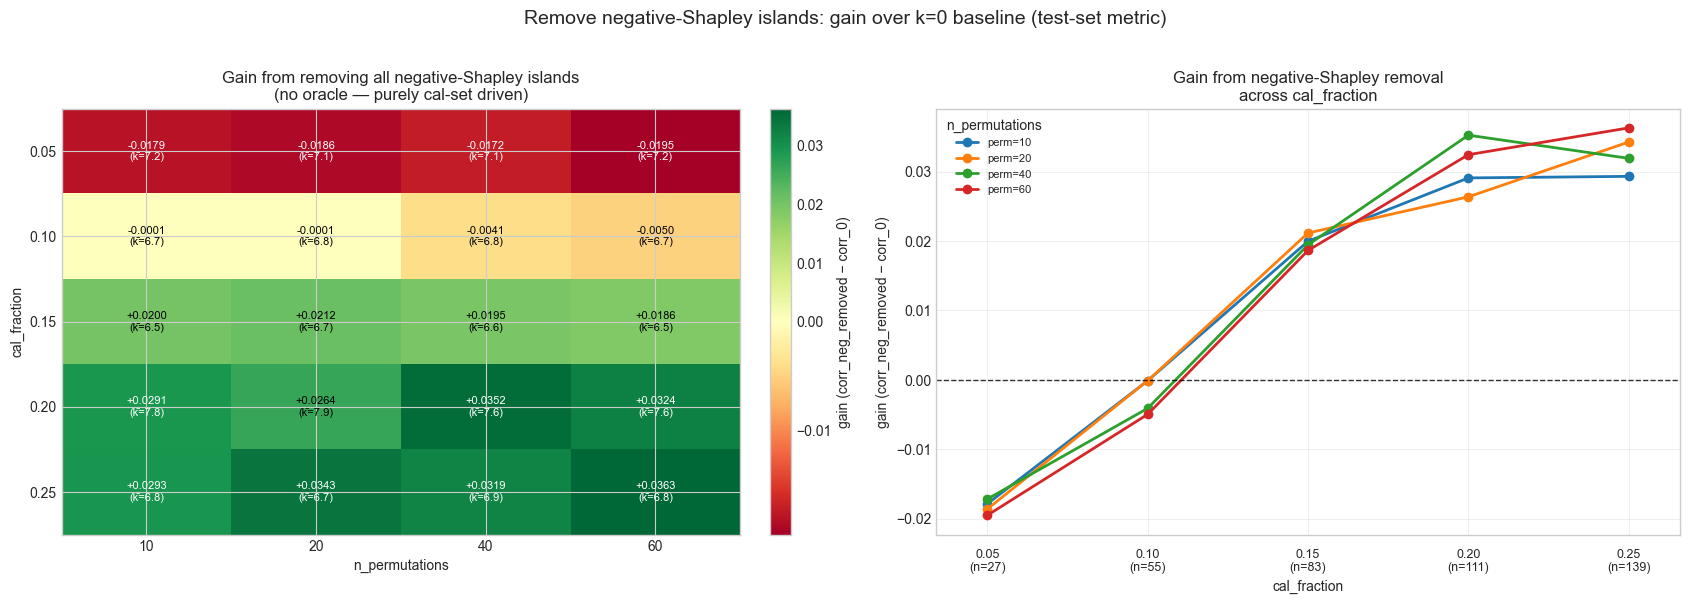

In [126]:
import matplotlib.colors as mcolors

# Extract shapley_mean remove-curve rows (per repeat)
shap_raw = raw_remove_df[raw_remove_df["method"] == "shapley_mean"].copy()

# Merge to get corr_eval at n_removed = k_neg for each (n_perm, cal_frac, repeat)
neg_merged = neg_df.merge(
    shap_raw[["n_permutations", "cal_fraction", "repeat", "n_removed", "corr_eval"]],
    left_on=["n_permutations", "cal_fraction", "repeat", "k_neg"],
    right_on=["n_permutations", "cal_fraction", "repeat", "n_removed"],
    how="left",
).rename(columns={"corr_eval": "corr_at_k_neg"})

# Also get corr at n_removed=0 as baseline
baseline_raw = (
    shap_raw[shap_raw["n_removed"] == 0]
    [["n_permutations", "cal_fraction", "repeat", "corr_eval"]]
    .rename(columns={"corr_eval": "corr_0"})
)
neg_merged = neg_merged.merge(baseline_raw, on=["n_permutations", "cal_fraction", "repeat"], how="left")
neg_merged["gain_neg_removal"] = neg_merged["corr_at_k_neg"] - neg_merged["corr_0"]

# For k_neg=0, corr_at_k_neg should equal corr_0 → gain=0
# Handle NaN from merge (if k_neg exceeds max n_removed)
neg_merged.loc[neg_merged["k_neg"] == 0, "gain_neg_removal"] = 0.0

# Average across repeats
neg_summary = (
    neg_merged.groupby(["n_permutations", "cal_fraction"], as_index=False)
    .agg(
        k_neg_mean=("k_neg", "mean"),
        k_neg_std=("k_neg", "std"),
        corr_at_k_neg_mean=("corr_at_k_neg", "mean"),
        corr_0_mean=("corr_0", "mean"),
        gain_mean=("gain_neg_removal", "mean"),
        gain_std=("gain_neg_removal", "std"),
        n_repeats=("k_neg", "size"),
    )
)

print("Negative-Shapley removal summary:")
display(neg_summary.sort_values(["cal_fraction", "n_permutations"]))

# -- Also load oracle gain for comparison --
oracle_gain = gain_df[["n_permutations", "cal_fraction", "gain_over_baseline", "best_n_removed"]].copy()
compare = neg_summary.merge(oracle_gain, on=["n_permutations", "cal_fraction"], how="left")
compare["pct_of_oracle"] = np.where(
    compare["gain_over_baseline"] > 0,
    compare["gain_mean"] / compare["gain_over_baseline"] * 100,
    np.nan,
)
print("\nComparison: negative-Shapley removal vs oracle best-k:")
display(compare[["n_permutations", "cal_fraction", "k_neg_mean", "gain_mean",
                  "best_n_removed", "gain_over_baseline", "pct_of_oracle"]]
        .sort_values(["cal_fraction", "n_permutations"]))

# ---- Heatmaps ----
gain_neg_grid = (
    neg_summary.pivot(index="cal_fraction", columns="n_permutations", values="gain_mean")
    .sort_index(axis=0).sort_index(axis=1)
)
k_neg_grid = (
    neg_summary.pivot(index="cal_fraction", columns="n_permutations", values="k_neg_mean")
    .sort_index(axis=0).sort_index(axis=1)
)

vals = gain_neg_grid.to_numpy(dtype=float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)

if vmin < 0 < vmax:
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
elif vmin >= 0:
    norm = mcolors.Normalize(vmin=0, vmax=max(vmax, 1e-6))
else:
    norm = mcolors.Normalize(vmin=vmin, vmax=0)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.4))

# Panel A: heatmap of gain from negative-Shapley removal
ax = axes[0]
im = ax.imshow(gain_neg_grid.values, aspect="auto", cmap="RdYlGn", norm=norm)
ax.set_title("Gain from removing all negative-Shapley islands\n(no oracle — purely cal-set driven)")
ax.set_xlabel("n_permutations")
ax.set_ylabel("cal_fraction")
ax.set_xticks(np.arange(len(gain_neg_grid.columns)))
ax.set_xticklabels(gain_neg_grid.columns.astype(int).tolist())
ax.set_yticks(np.arange(len(gain_neg_grid.index)))
ax.set_yticklabels([f"{x:.2f}" for x in gain_neg_grid.index])

for i in range(gain_neg_grid.shape[0]):
    for j in range(gain_neg_grid.shape[1]):
        g_val = gain_neg_grid.iat[i, j]
        k_val = k_neg_grid.iat[i, j]
        text_color = "black" if abs(g_val - (vmin + vmax) / 2) < (vmax - vmin) * 0.35 else "white"
        ax.text(j, i, f"{g_val:+.4f}\n(k̄={k_val:.1f})", ha="center", va="center", fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.048, pad=0.04)
cbar.set_label("gain (corr_neg_removed − corr_0)")

# Panel B: trend lines by n_permutations (x-axis = cal_fraction)
ax = axes[1]
for n_perm in gain_neg_grid.columns:
    y = gain_neg_grid[n_perm].values.astype(float)
    x = gain_neg_grid.index.values.astype(float)
    ax.plot(x, y, marker="o", linewidth=2, label=f"perm={int(n_perm)}")

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Gain from negative-Shapley removal\nacross cal_fraction")
ax.set_ylabel("gain (corr_neg_removed − corr_0)")
ax.legend(loc="best", fontsize=8, title="n_permutations")
ax.grid(alpha=0.3)

# x-axis labels: cal_fraction + cal_samples
x_ticks = gain_neg_grid.index.values.astype(float)
ax.set_xticks(x_ticks)

local_cal_samples_map = cal_samples_map if ("cal_samples_map" in globals() and cal_samples_map) else {}
if not local_cal_samples_map and "get_cal_sample_map" in globals():
    effective_target = int(meta_df["target_island"].mode().iloc[0])
    local_cal_samples_map = get_cal_sample_map(effective_target)

if local_cal_samples_map:
    x_labels = []
    for cf in x_ticks:
        nearest = min(local_cal_samples_map.keys(), key=lambda k: abs(k - float(cf)))
        x_labels.append(f"{cf:.2f}\n(n={local_cal_samples_map[nearest]})")
    ax.set_xticklabels(x_labels)
else:
    ax.set_xticklabels([f"{cf:.2f}" for cf in x_ticks])
ax.set_xlabel("cal_fraction")
ax.tick_params(axis="x", labelsize=9, pad=10)
ax.margins(x=0.08)

fig.suptitle("Remove negative-Shapley islands: gain over k=0 baseline (test-set metric)", fontsize=14, y=1.02)
fig.tight_layout()
fig.subplots_adjust(bottom=0.20)
plt.show()